In [1]:
from run_inference import *
from opas.utils import seed_everything

def load_models(name="best", expt_id=None, device="cpu"):
    if expt_id is None:
        expt_id = experiment_id

    if name not in ["best", "last", "latest"]:
        raise NotImplementedError("Only `best`, `last`, and `latest` models are supported")
    
    if name=="best":
        suffix = ""
    else:
        suffix = f"_{name}"
    
    print(f"Loading `{name}` model")

    model = torch.load(f"models/{expt_id}/model{suffix}.pt", map_location=device)
    scoremodel = torch.load(f"models/{expt_id}/scmodel{suffix}.pt", map_location=device)
    embed_model = torch.load(f"models/{expt_id}/embed_model{suffix}.pt", map_location=device)
    if os.path.exists(f"models/{expt_id}/preembed_model{suffix}.pt"):
        preembed_model = torch.load(f"models/{expt_id}/preembed_model{suffix}.pt", map_location=device)
    else:
        tokenize_transform = lambda x: tokenize(x, args)[0]
        preembed_model = TransformInput(tokenize_transform).to(device)
    
    if os.path.exists(f"models/{expt_id}/aggregator{suffix}.pt"):
        aggregator = torch.load(f"models/{expt_id}/aggregator{suffix}.pt", map_location=device)
    else:
        aggregator = None

    return model, scoremodel, embed_model, preembed_model, aggregator

@torch.no_grad()
def compute_scores(dataset, model, scoremodel, embed_model, preembed_model, image_embed_model=None, stagger=2, verbose=False, aggregator=None):
    loader = dataset.get_dataloader(batch_size=100, shuffle=True)

    C = embed_full_corpus(dataset, embed_model, preembed_model, image_embed_model=image_embed_model, aggregator=aggregator)
    C_orig = torch.from_numpy(dataset.c).float()
    # C is (N, n, xoutdim)

    normscores = []
    lamscores = []
    netscores = []
    true_labels = []
    alignments = []
    true_alignments = []
    num_pos_samps = 0
    for n, (q, l) in enumerate(tqdm(loader, leave=False, disable=not verbose)):
        batch_alignments = []
        for k in range(len(q)):
            q_ = q[k].flatten(start_dim=1)
            l_ = l[k]
            matching_corpus = C_orig[l_.nonzero().squeeze()]
            curr_alignments = []
            for kk in range(len(matching_corpus)):
                ckk = matching_corpus[kk].flatten(start_dim=1)
                qct = normalize(q_) @ normalize(ckk).T
                maxidxs = torch.argmax(qct, dim=1)
                true_p = torch.zeros_like(qct)
                true_p[torch.arange(len(qct)), maxidxs] = 1
                curr_alignments.append(true_p)

                # for qiter in range(6):
                #     mindistidx = np.argmin([F.mse_loss(q_[qiter], ckk[citer]) for citer in range(20)])
                #     curr_alignments.append(mindistidx)
            batch_alignments.append(torch.stack(curr_alignments))
        true_alignments.append(torch.stack(batch_alignments))            

        q = q.to(next(model.parameters()).device) 
        # q is bmd, c is Nnd, l is bN
        q = q + batch_get_white_noise(q, args.SNR)     # torch.randn_like(q) * noise
        q = embed_if_image_and_normalize(q, image_embed_model)
        q = embed_model(preembed_model(q))
        q = normalize(q)

        # q is (b, m, xoutdim)
        if aggregator is None:
            qct = torch.einsum("bmd,Nnd->bNmn", q, C)
            if isinstance(model, LamModel):
                model_inputs = stagger_and_concat(qct, num_stagger=stagger) # bNsmn  s = num_stagger+1

                lambdas = torch.stack([model(x) for x in model_inputs])
                # bNm1
            else:
                lambdas = []
                for xx in range(len(q)):
                    q_ = q[xx].unsqueeze(0)
                    q_ = q_.repeat_interleave(C.shape[0], dim=0)
                    lambdas_ = model(torch.cat((q_, C), dim=1).flatten(start_dim=1)).unsqueeze(-1)
                    lambdas.append(lambdas_)
                lambdas = torch.stack(lambdas)

            F_mat = Rm_mat.T @ (2*qct + (a_vec @ lambdas.transpose(2,3) @ A_mat).transpose(2,3))

            P = gumbel_sinkhorn(F_mat, CFG.tau, 100, noise=False)

            RmPC = Rm_mat @ P @ C.squeeze(-1)

            lamscore = lamwt * (lambdas.transpose(2,3) @ F.relu(b-A_mat @ Rm_mat @ P @ a_vec)).squeeze()
            normscore = torch.norm(q.unsqueeze(1) - RmPC, dim=[-1,-2])

            allscores = torch.stack([lamscore, normscore], dim=2)
            netscore = 2*scoremodel(-allscores).squeeze()      # b

        else:
            q = aggregator(q)
            # q is bd, C is Nd, we want bN scores
            # b1d - 1Nd = bNd --> sum across last dim to get bN scores
            netscore = 2 * F.sigmoid(-F.relu(q.unsqueeze(1) - C.unsqueeze(0)).sum(dim=-1))    # bN

        normscores.append(normscore.to('cpu'))
        lamscores.append(lamscore.to('cpu'))
        netscores.append(netscore.to('cpu'))
        true_labels.append(l.to('cpu'))
        alignments_ = []
        for k in range(len(P)):
            alignments_.append(P[k][l[k].nonzero().squeeze().to('cpu')][...,:6,:])
        alignments_ = torch.stack(alignments_)
        alignments.append(alignments_)
        # num_pos_samps += l.sum().item()
        # print(num_pos_samps)
        # if num_pos_samps >= 5000:
        #     print("breaking")
        #     break

    netscores = torch.vstack(netscores).cpu()
    true_labels = torch.vstack(true_labels).squeeze().cpu() # 
    normscores = torch.vstack(normscores).cpu()
    lamscores = torch.vstack(lamscores).cpu()
    alignments = torch.vstack(alignments).cpu()
    true_alignments = torch.vstack(true_alignments).cpu()

    return netscores, normscores, lamscores, true_labels, alignments, true_alignments

In [2]:
# try:
#     import pickle
#     with open("plots_and_figures/alignments_and_scores.pkl", "rb") as file:
#         all_scores = pickle.load(file)

#     pos_all = all_scores["pos"]
#     neg_all = all_scores["neg"]
#     alignments_all = all_scores["alignments"]
#     true_alignments_all = all_scores["true_alignments"]

# except:
#     pos_all = {}
#     neg_all = {}
#     alignments_all = {}
#     true_alignments_all = {}


# for expt_id in ["C30082224", "A01091914", "AH05092001", "L13090014"]:
#     args = argparse.Namespace(expt_id=expt_id, device=0)

#     experiment_id = args.expt_id
#     expt_root = f"models/{experiment_id}/"
#     args.device = 1
#     DEVICE = f"cuda:3" if torch.cuda.is_available() and args.device != -1 else "cpu"

#     with open(os.path.join(expt_root, "args.pkl"), "rb") as file:
#         args = pickle.load(file)

#     model, scoremodel, embed_model, preembed_model, aggregator = load_models(name="best", expt_id=experiment_id, device=DEVICE)
#     model.eval(), scoremodel.eval(), embed_model.eval(), preembed_model.eval()
#     if aggregator is not None:
#         aggregator.eval()

#     nwt, lamwt = next(scoremodel.parameters()).exp().detach().cpu()
#     nwt, lamwt = nwt.item(), lamwt.item()

#     print(f"normscore weight: {nwt:.4f}, lamscore weight: {lamwt:.4f}")

#     dataset = args.dataset 
#     dataset = "speech" if dataset == "human" else dataset
#     dataset = "lsun" if dataset == "lsun384" else dataset
#     DATA_ROOT = f"final_data/{dataset}"
#     TEST_FILE = f"{DATA_ROOT}/dataset_test.hdf5"
#     NOLAMMODEL = args.__dict__.get("no_lammodel", False)

#     image_embed_model = None
#     if "cifar" in dataset:
#         image_embed_model_ckpt = "data/image_sequence/embedding_models/cifar_ae.pkl"
#         image_embed_model = Autoencoder()
#         image_embed_model.load_state_dict(torch.load(image_embed_model_ckpt))
#         image_embed_model.eval()

#         for param in image_embed_model.parameters():
#             param.requires_grad = False

#         image_embed_model = image_embed_model.to(DEVICE)
#         TEST_FILE = f"{DATA_ROOT}/dataset_test_orig.hdf5"

#     if "lsun" in dataset:
#         image_embed_model_ckpt = "data/image_sequence/embedding_models/lsun_ae.pkl"
#         image_embed_model = LSUNAutoencoder()
#         image_embed_model.load_state_dict(torch.load(image_embed_model_ckpt))
#         image_embed_model.eval()

#         for param in image_embed_model.parameters():
#             param.requires_grad = False

#         image_embed_model = image_embed_model.to(DEVICE)
#         TEST_FILE = f"{DATA_ROOT}/dataset_test_orig.hdf5"

#     test_dataset = PairDatasetTest(TEST_FILE)
#     print(f"test subset of dataset: \"{dataset}\" loaded from {TEST_FILE}")

#     ##### HPARAMS ######
#     b = args.b          # hinge margin for negative gap penalty (b-Apa)
#     b1 = args.b1         # hinge margin for positive gap penalty (Apa-b)
#     delta = args.delta     # hinge margin for contrastive loss
#     lr = args.lr
#     nepochs = args.nepochs
#     stagger = args.stagger
#     lamwt = args.lamwt    # loss coefficient for negative gap penalty
#     gapwt = args.gapwt       # loss coefficient for positive gap penalty
#     M = 6
#     N = 20
#     ####################

#     A_mat, a_vec, Rm_mat = get_opas_constants(M, N, DEVICE)

#     CFG = AttributeDict({
#         'tau': 1,
#         'n_sink_iter': 20,
#         'n_samples': 1,
#     })

#     netscores, normscores, lamscores, true_labels, alignments, true_alignments = compute_scores(test_dataset, model, scoremodel, embed_model, preembed_model, image_embed_model=image_embed_model, stagger=stagger, verbose=True, aggregator=aggregator)

#     all_pos_scores = [
#         netscores[true_labels==1],
#         normscores[true_labels==1],
#         lamscores[true_labels==1]
#     ]
#     all_neg_scores = [
#         netscores[true_labels==0],
#         normscores[true_labels==0],
#         lamscores[true_labels==0]
#     ]

#     pos_all[dataset] = all_pos_scores
#     neg_all[dataset] = all_neg_scores
#     alignments_all[dataset] = alignments
#     true_alignments_all[dataset] = true_alignments

In [ ]:
# all_scores = {
#     "pos": pos_all,
#     "neg": neg_all,
#     "alignments": alignments_all,
#     "true_alignments": true_alignments_all
# }
# with open("plots_and_figures/alignments_and_scores.pkl", "wb") as file:
#     pickle.dump(all_scores, file)

In [3]:
from matplotlib import font_manager
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import gaussian_kde

font = font_manager.FontEntry(fname="plots_and_figures/arial.ttf", name="Arial")
font_manager.fontManager.ttflist.append(font)

mpl.rcParams['font.family'] = "Arial"

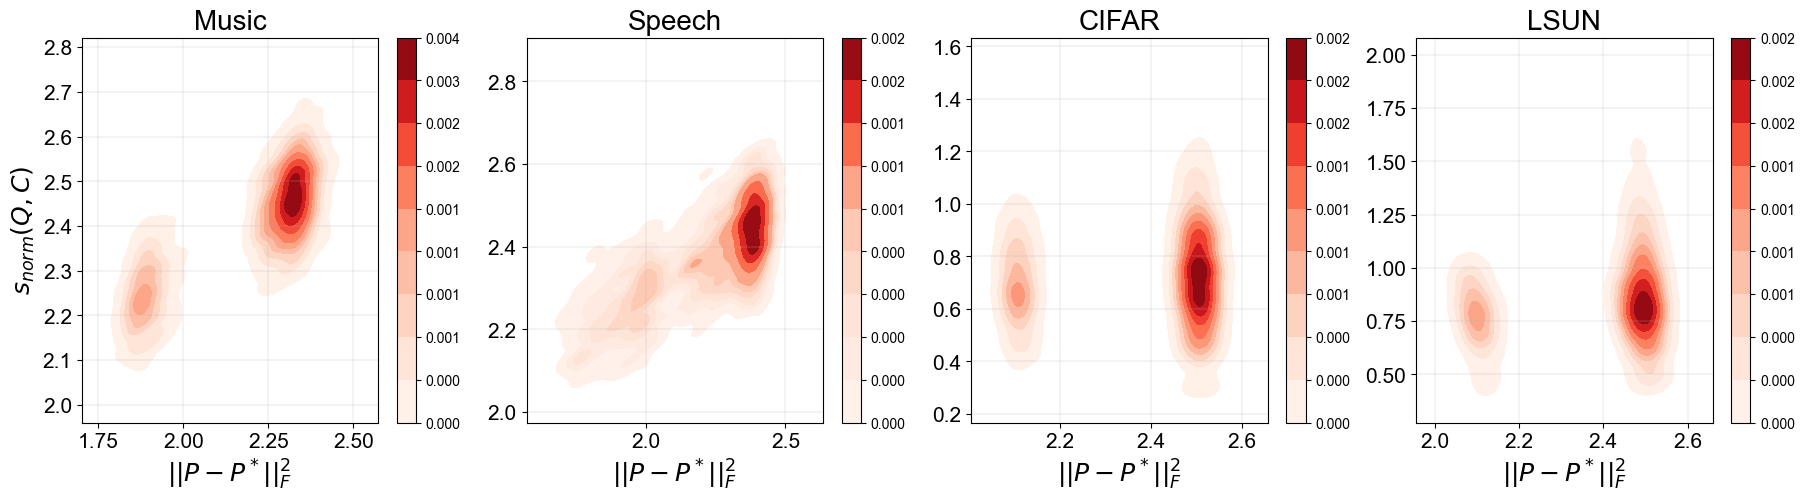

In [ ]:
import pickle
with open("plots_and_figures/alignments_and_scores.pkl", "rb") as file:
    all_scores = pickle.load(file)

al, gt = all_scores["alignments"], all_scores["true_alignments"]
pos_all = all_scores["pos"]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
axes = axes.flatten()

plot_markersize = 10
opas_markersize = 250
opas_idmarkersize = 200
axis_fontsize = 18
title_fontsize = 20
label_fontsize = 15

xfm = lambda x: x.capitalize() if x not in ["cifar", "lsun"] else x.upper()

for n, dataset in enumerate(["audio", "speech", "cifar", "lsun"]):
    al_, gt_ = al[dataset], gt[dataset]
    diffs = (al_ - gt_).norm(dim=[-1,-2]).flatten().numpy()
    ps = pos_all[dataset][1].numpy()    # normscores
    np.random.seed(8)
    nsamps = 10000
    idxs = np.random.choice(range(len(ps)), nsamps, replace=False)
    
    dataset = "music" if dataset == "audio" else dataset
    ####### matplotlib ###############
    # x, y = diffs[idxs], ps[idxs]
    # k = gaussian_kde([x, y])
    
    # nbins = 500
    # xi, yi = np.mgrid[
    #     x.min():x.max():nbins*1j,
    #     y.min():y.max():nbins*1j
    # ]
    # zi = k(np.vstack([
    #     xi.flatten(),
    #     yi.flatten()
    # ])).reshape(xi.shape) / nsamps
    # cm = axes[n].pcolormesh(xi, yi, zi, cmap=plt.cm.Reds)
    # cbar = plt.colorbar(cm, ax=axes[n])
    # cbar.ax.set_yticklabels(np.arange(0, 1, 0.1), fontsize=16, weight='bold')
    # axes[n].contour(xi, yi, zi.reshape(xi.shape), linewidths=0.5, colors='black')
    ##################################

    kplot = sns.kdeplot(y=ps[idxs], x=diffs[idxs], cmap='Reds', fill=True, bw_adjust=0.7, ax=axes[n], thresh=0.05, common_norm=False, cbar=True)
    # cbar = plt.colorbar(kplot, ax=axes[n])

    if n == 0:
        axes[n].set_ylabel(r"$s_{norm}(Q,C)$", fontsize=axis_fontsize)
    else:
        axes[n].set_ylabel("")
    axes[n].set_xlabel(r"$||P-P^*||_F^2$", fontsize=axis_fontsize)
    axes[n].set_title(f"{xfm(dataset)}", fontsize=title_fontsize)
    axes[n].tick_params(axis='both', which='major', labelsize=label_fontsize)
    axes[n].grid(linewidth=0.2)

cbars = fig.get_children()[-4:]
for i in range(4):
    yticklabels = cbars[i].get_yticklabels()
    newlabels = []
    for j in range(len(yticklabels)):
        yticklabels[j].set_text(f"{float(yticklabels[j].get_text())/nsamps:.3f}")
        newlabels.append(yticklabels[j])
    cbars[i].set_yticklabels(newlabels)

#     handles, labels = axes[n].get_legend_handles_labels()

# legend = fig.legend(handles, labels, loc='upper center', ncol=5, fontsize=13)
# coords = legend.get_window_extent().get_points()[0]
# fig.legends = []
# scale = fig.get_window_extent().get_points()[1]
# fig.legend(handles, labels, bbox_to_anchor=(coords[0]/(scale[0]), coords[1]/(scale[1])+0.17), loc=2, ncol=5, fontsize=15)
fig.savefig('plots_and_figures/scores_vs_alignment_diffs_sns_normqc.pdf', bbox_inches='tight')
plt.show()

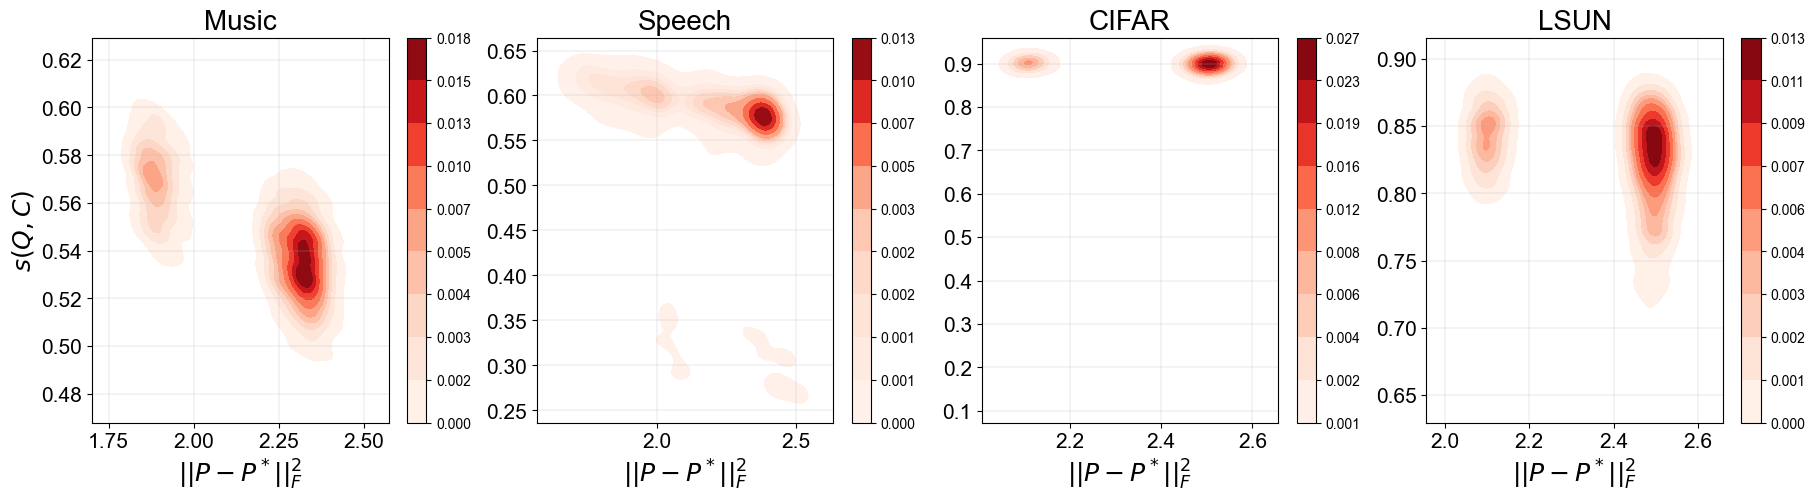

In [5]:
import pickle
with open("plots_and_figures/alignments_and_scores.pkl", "rb") as file:
    all_scores = pickle.load(file)

al, gt = all_scores["alignments"], all_scores["true_alignments"]
pos_all = all_scores["pos"]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
axes = axes.flatten()

plot_markersize = 10
opas_markersize = 250
opas_idmarkersize = 200
axis_fontsize = 18
title_fontsize = 20
label_fontsize = 15

xfm = lambda x: x.capitalize() if x not in ["cifar", "lsun"] else x.upper()

for n, dataset in enumerate(["audio", "speech", "cifar", "lsun"]):
    al_, gt_ = al[dataset], gt[dataset]
    diffs = (al_ - gt_).norm(dim=[-1,-2]).flatten().numpy()
    ps = pos_all[dataset][0].numpy()    # netscores
    np.random.seed(8)
    nsamps = 10000
    idxs = np.random.choice(range(len(ps)), nsamps, replace=False)
    
    dataset = "music" if dataset == "audio" else dataset
    ####### matplotlib ###############
    # x, y = diffs[idxs], ps[idxs]
    # k = gaussian_kde([x, y])
    
    # nbins = 500
    # xi, yi = np.mgrid[
    #     x.min():x.max():nbins*1j,
    #     y.min():y.max():nbins*1j
    # ]
    # zi = k(np.vstack([
    #     xi.flatten(),
    #     yi.flatten()
    # ])).reshape(xi.shape) / nsamps
    # cm = axes[n].pcolormesh(xi, yi, zi, cmap=plt.cm.Reds)
    # cbar = plt.colorbar(cm, ax=axes[n])
    # cbar.ax.set_yticklabels(np.arange(0, 1, 0.1), fontsize=16, weight='bold')
    # axes[n].contour(xi, yi, zi.reshape(xi.shape), linewidths=0.5, colors='black')
    ##################################

    kplot = sns.kdeplot(y=ps[idxs], x=diffs[idxs], cmap='Reds', fill=True, bw_adjust=0.7, ax=axes[n], thresh=0.05, common_norm=False, cbar=True)
    # cbar = plt.colorbar(kplot, ax=axes[n])

    if n == 0:
        axes[n].set_ylabel(r"$s(Q,C)$", fontsize=axis_fontsize)
    else:
        axes[n].set_ylabel("")
    axes[n].set_xlabel(r"$||P-P^*||_F^2$", fontsize=axis_fontsize)
    axes[n].set_title(f"{xfm(dataset)}", fontsize=title_fontsize)
    axes[n].tick_params(axis='both', which='major', labelsize=label_fontsize)
    axes[n].grid(linewidth=0.2)

cbars = fig.get_children()[-4:]
for i in range(4):
    yticklabels = cbars[i].get_yticklabels()
    newlabels = []
    for j in range(len(yticklabels)):
        yticklabels[j].set_text(f"{float(yticklabels[j].get_text())/nsamps:.3f}")
        newlabels.append(yticklabels[j])
    cbars[i].set_yticklabels(newlabels)

#     handles, labels = axes[n].get_legend_handles_labels()

# legend = fig.legend(handles, labels, loc='upper center', ncol=5, fontsize=13)
# coords = legend.get_window_extent().get_points()[0]
# fig.legends = []
# scale = fig.get_window_extent().get_points()[1]
# fig.legend(handles, labels, bbox_to_anchor=(coords[0]/(scale[0]), coords[1]/(scale[1])+0.17), loc=2, ncol=5, fontsize=15)
fig.savefig('plots_and_figures/scores_vs_alignment_diffs_sns_sqc.pdf', bbox_inches='tight')
plt.show()